# **RISK MEASUREMENT ASSIGNMENT**

<u>GROUP 3:</u>
- Gabriel ANZALONE
- Ndeye Arame MBENGUE
- Edoardo NICOLETTI


## **1- Data Preparation**

### - Loading the Data

In [ ]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Reading the Excel File
file_path = "842 Risk Measurement Hallerbach - data for group assignment.xlsx"
df = pd.read_excel(file_path, sheet_name=None,skiprows= 9)
df = df['daily_data']
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [74]:
df.head()

,Mkt,Tsies,CorpIG,CorpHY,AR,Oil
date,,,,,,
1994-12-30,1.000000,1.000000,1.000000,1.000000,1.000000,17.77
1995-01-03,0.997600,0.997267,0.997864,1.000572,1.008810,17.45
1995-01-04,1.001092,1.001366,1.001542,1.002199,1.015014,17.56
1995-01-05,1.000791,0.997262,0.999229,1.004223,1.014720,17.76
1995-01-06,1.002793,0.997943,1.000934,1.002199,1.013431,17.69


###  - Inspecting the data

In [ ]:
# First, counting the number of NANs for each asset class & checking the min/max values Total Return Index levels for each asset class
print(df.isna().sum())
print(df.describe().loc[['min', 'max']])
# Checking for duplicated rows (dates)
print(df.index.duplicated().sum())


Mkt       0
Tsies     0
CorpIG    0
CorpHY    0
AR        0
Oil       0
dtype: int64
           Mkt     Tsies    CorpIG    CorpHY        AR     Oil
min   0.997600  0.996580  0.997864  1.000000  0.852990  -36.98
max  23.293702  1.764456  5.320129  7.636756  9.859741  145.31
0


<b><u>Comment:</b></u>
- No missing values (NANs) were detected in the dataset.
- Min and max values show differences across asset classes, but remain logical given the nature of the assets.
- For the Oil index, a negative value (around -37) appears, corresponding to the historic event on 20-Apr-2020 when oil futures prices briefly turned negative due to the COVID-19 market disruption.

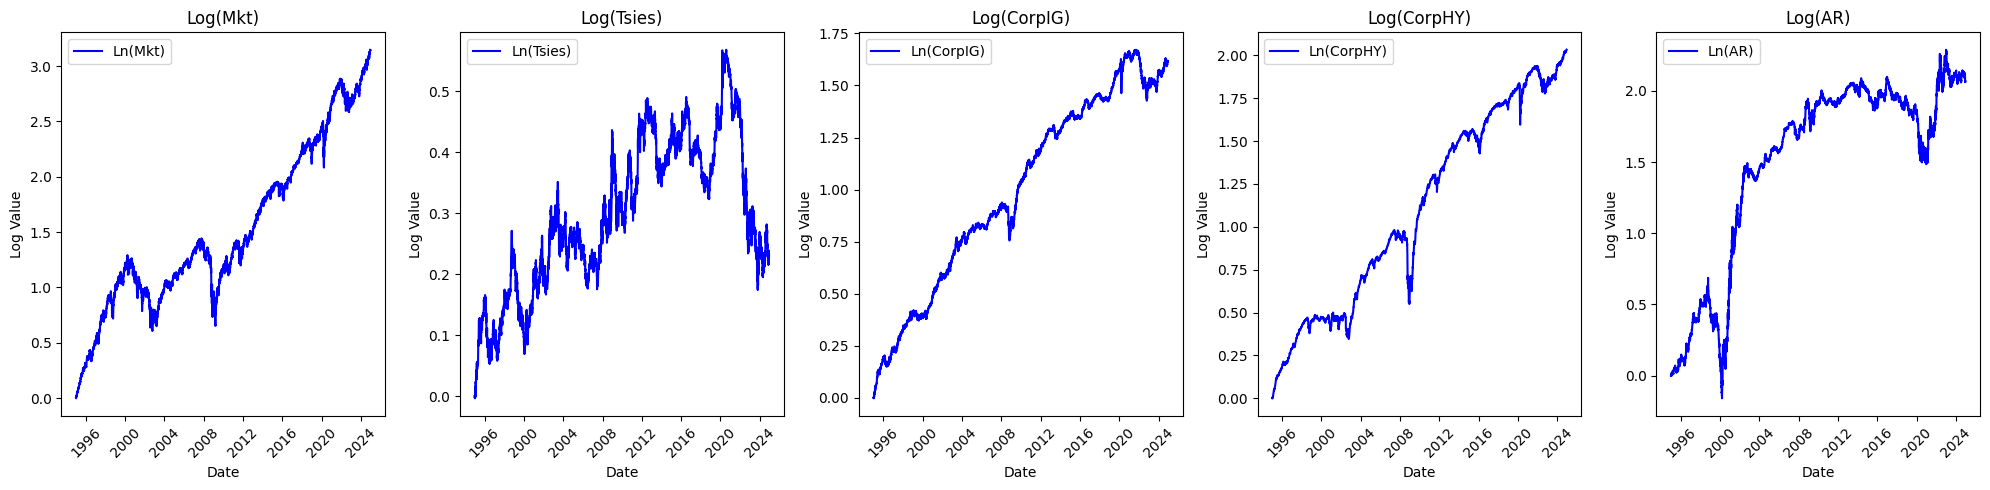

In [13]:
# Plotting log(index) for Mkt, Tsies, CorpIG, CorpHY & AR first:
num_columns_first = 5
fig, axes = plt.subplots(1, num_columns_first, figsize=(20, 5))
for i, column in enumerate(df.columns[:num_columns_first]):
    log_index = np.log(df[column])
    axes[i].plot(df.index, log_index, label=f'Ln({column})', color='blue')
    axes[i].set_title(f'Log({column})')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Log Value')
    axes[i].legend()
    axes[i].grid(False)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

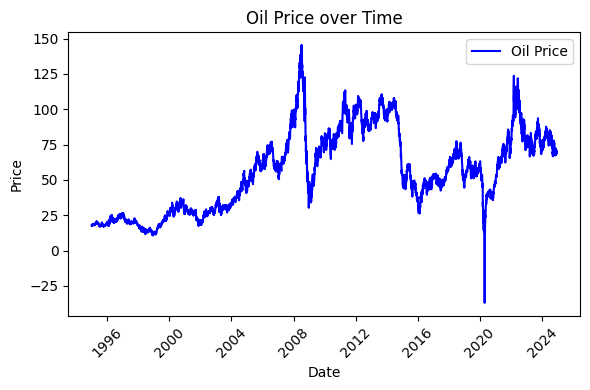

In [14]:
# Plotting the Oil price over time
plt.figure(figsize=(6, 4))
plt.plot(df.index, df['Oil'], label='Oil Price', color='blue')
plt.title('Oil Price over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b><u>Comment:</b></u>
- We will replace the negative oil price observed on April 20th 2020 by the previous value if it is positive -> Using the previous non-missing level value (kind of winsorizing). Otherwise, it would bias all return statistics.

In [15]:
df['Oil'].idxmin()

Timestamp('2020-04-20 00:00:00')

In [16]:
min_oil_date = '2020-04-20'
df.loc[min_oil_date, 'Oil'] = df['Oil'].shift(1).loc[min_oil_date]

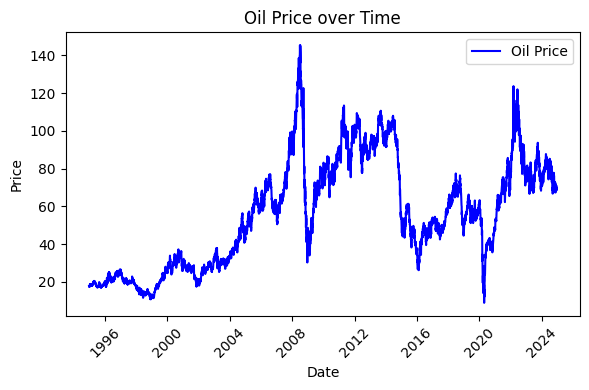

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(df.index, df['Oil'], label='Oil Price', color='blue')
plt.title('Oil Price over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### <u>RQ1–volatility: What are the ex-ante volatilities of the augmented & default portfolios on Wednesday 11-Dec-2024 close and how does this compare against the course of these ex-ante volatilities over time ?

<u>Volatility horizon ?</u>
- Daily: We select a daily volatility horizon because the data are available at daily frequency, and we are focused on estimating ex-ante volatility for a specific trading date (11-Dec-2024).
- Moreover, a daily horizon is consistent with the portfolio manager's weekly trading frequency, as well as the regulatory requirements for daily risk metrics reporting.

<u>Model ?</u>  

We considered three models for volatility estimation:
- Equally Weighted (EW) historical volatility:
Problem: EW assigns equal weights to all past observations, resulting in no information decay.
Consequence: The model is not sufficiently responsive to recent market conditions, which is undesirable for accurate ex-ante risk measurement.

- GARCH(1,1) volatility modeling:
Problem: Although GARCH captures volatility clustering and mean-reversion, it is relatively cumbersome in a multi-asset context because it requires estimating three parameters per series (ω, α, β) via Maximum Likelihood Estimation (MLE).
Consequence: The computational cost and complexity increase substantially without necessarily improving short-term volatility forecasting​​.

- EWMA (Exponentially Weighted Moving Average) volatility:
Advantages:
    - Retains exponentially declining weights, ensuring information decay.
    - Reduces ghost effects (sudden jumps in volatility when old observations drop out).
    - Simple, robust, and performs well in practice, particularly for financial markets.
Caveats:
    - Ignores long-term mean reversion (no unconditional variance).
    - Non-stationary variance process (strictly speaking), but not problematic empirically.

- Our Decision:  We decided to compare EWMA volatility (λ = 0.94) and GARCH(1,1) volatility.
EWMA λ = 0.94 is a standard industry setting (RiskMetrics) corresponding to a half-life of approximately 11 days, giving recent observations more influence.

<u>Comparison Methodology</u>

We split the dataset into:
Training sample: 1995–2010 
Testing sample: 2014–2024

We evaluate model performance over the out-of-sample (testing) period using two of the four evaluation criteria seen in Lecture 4:
- Bias (average precision): whether z-scores (returns normalized by volatility) have a standard deviation close to 1.
- Distribution (fat tails): whether z-scores have reduced excess kurtosis (better-behaved distribution).
(We omit criteria related to time variation of bias and relative Quasi Likelihood for simplicity.)

In [81]:
# If we cut the period in 2
returns = np.log(df / df.shift(1))
returns = returns.dropna()
train_start = '2010-01-01'
train_end = '2024-12-31'
test_start = '1995-01-03'
test_end = '2010-12-31'
train_set = returns[(returns.index >= train_start) & (returns.index <= train_end)]
test_set = returns[(returns.index >= test_start) & (returns.index <= test_end)]

In [82]:
print(train_set.shape)
print(test_set.shape) # so quite the same length/ one year approx more of data in the test_set

(3761, 6)
(4030, 6)


In [83]:
test_set

,Mkt,Tsies,CorpIG,CorpHY,AR,Oil
date,,,,,,
1995-01-03,-0.002403,-0.002736,-0.002138,0.000572,0.008771,-0.018172
1995-01-04,0.003494,0.004101,0.003679,0.001625,0.006131,0.006284
1995-01-05,-0.000300,-0.004107,-0.002313,0.002017,-0.000290,0.011325
1995-01-06,0.001998,0.000683,0.001705,-0.002017,-0.001271,-0.003949
1995-01-09,0.001000,-0.001367,-0.001468,0.000527,-0.003657,-0.016529
...,...,...,...,...,...,...
2010-12-27,0.000810,0.004208,0.003038,0.001121,0.001898,0.001650
2010-12-28,0.000010,-0.011796,-0.006482,0.000598,0.000080,0.005371
2010-12-29,0.001709,0.012578,0.008287,0.001284,-0.001321,-0.003833


In [84]:
train_set

,Mkt,Tsies,CorpIG,CorpHY,AR,Oil
date,,,,,,
2010-01-04,0.016759,0.000000,0.001919,0.003759,0.008087,0.026476
2010-01-05,0.003095,0.006592,0.006749,0.004832,0.008573,0.002695
2010-01-06,0.001299,-0.006610,-0.001611,0.004535,0.005027,0.016742
2010-01-07,0.003992,0.000000,0.000337,0.004901,0.003564,-0.006276
2010-01-08,0.003295,0.001647,0.002225,0.001934,-0.000980,0.001693
...,...,...,...,...,...,...
2024-12-05,-0.002633,0.001620,0.000015,0.000473,0.006310,-0.003348
2024-12-06,0.003663,0.001622,0.001581,0.001135,-0.020335,0.000000
2024-12-09,-0.007256,-0.004057,-0.002228,0.000092,0.005962,0.001020


#### Forming the 2 portfolios

- Weight for default portfolio: 50% mkt, 30% Tsies, 5% CorpIG, 0% CorpHY, 10% AR, 5% Oil
- Weight for augmented portfolio: 40% mkt, 40% Tsies, 0% CorpIG, 5% CorpHY, 15% AR, 0% Oil

In [85]:
w_default = np.array([0.50, 0.30, 0.05, 0.00, 0.10, 0.05])
w_augmented = np.array([0.40, 0.40, 0.00, 0.05, 0.15, 0.00])

In [86]:
# Calculating returns for the training period first
ret_default_train = train_set @ w_default
ret_augmented_train = train_set @ w_augmented

In [87]:
returns = returns.rename(columns={0: 'Return'})
ret_default_train = pd.DataFrame(ret_default_train, columns=['Return'])
ret_augmented_train = pd.DataFrame(ret_augmented_train, columns=['Return'])

In [88]:
# Computing them for the testing period:
ret_default_test = test_set @ w_default
ret_augmented_test = test_set @ w_augmented

ret_default_test = pd.DataFrame(ret_default_test, columns=['Return'])
ret_augmented_test = pd.DataFrame(ret_augmented_test, columns=['Return'])

#### 1-A) EWMA (training set)

In [89]:
def ewma_volatility(returns, lambda_=0.94):
    squared_returns = returns**2
    ewma_var = [squared_returns.iloc[0,0]]

    for i in range(1, len(squared_returns)):  # Iterate using index -> change here as I renamed the column
        r2 = squared_returns.iloc[i, 0]
        ewma_prev = ewma_var[-1]
        ewma_new = lambda_ * ewma_prev + (1 - lambda_) * r2
        ewma_var.append(ewma_new)

    ewma_vol = pd.Series(np.sqrt(ewma_var), index=squared_returns.index[0:len(ewma_var)])
    return ewma_vol

In [90]:
vol_default_train=ewma_volatility(ret_default_train) #Vol for the default ptf on training period
vol_augmented_train=ewma_volatility(ret_augmented_train) #Vol for the augmented pptf

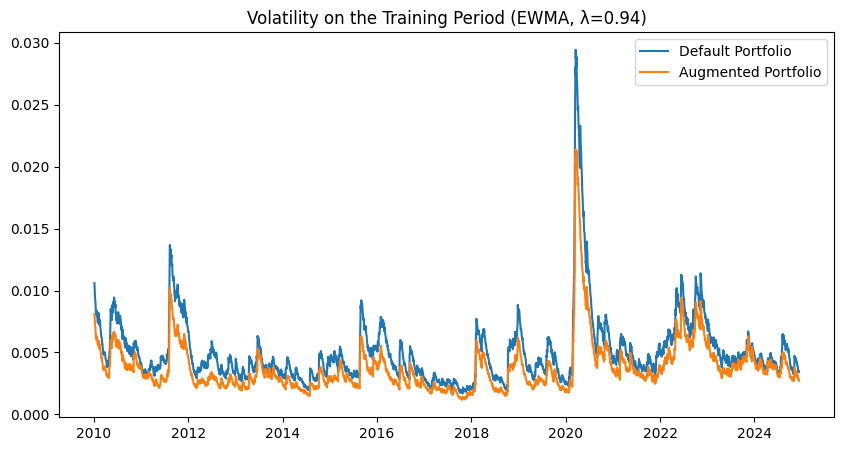

In [91]:
plt.figure(figsize=(10, 5))
plt.plot(vol_default_train, label='Default Portfolio')
plt.plot(vol_augmented_train, label='Augmented Portfolio')
plt.title("Volatility on the Training Period (EWMA, λ=0.94)")
plt.legend()
plt.show()

- Augmented portfolio consistently exhibits lower volatility, reflecting its more defensive allocation (more Treasuries, no Oil, reduced Equities).

<u>Estimation Approach ?</u>
- Computed daily log returns from price indices and constructed portfolio returns using the specified asset weights.
- EWMA volatility estimated both on training & testing period.

<u>Evaluation Criteria ?</u>
- Ex-Ante Volatility over time:the EWMA model captures historical spikes (e.g., 2020), showing meaningful differences between portfolios, particularly during periods of stress.

#### 1-B) EWMA (testing set)

In [92]:
vol_default_test_ewma=ewma_volatility(ret_default_test) # Vol for the default portfolio on training period
vol_augmented_test_ewma=ewma_volatility(ret_augmented_test) # Vol for the augmented portfolio on training period

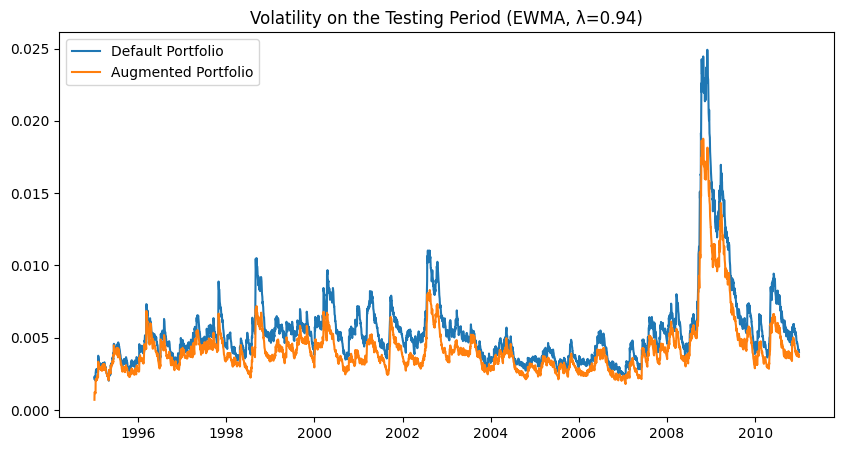

In [93]:
plt.figure(figsize=(10, 5))
plt.plot(vol_default_test_ewma, label='Default Portfolio')
plt.plot(vol_augmented_test_ewma, label='Augmented Portfolio')
#plt.axvline(x=decision_day, color='red', linestyle='--', label='Decision Day')
plt.title("Volatility on the Testing Period (EWMA, λ=0.94)")
plt.legend()
plt.show()

1st Criteria for EWMA: average bias

In [94]:
# Normalize returns using the EWMA conditional volatility
z_scores_default_ewma = ret_default_test['Return'] / vol_default_test_ewma
z_scores_augmented_ewma = ret_augmented_test['Return'] / vol_augmented_test_ewma

# Calculate the standard deviation of the z-scores
stdev_z_default_ewma = np.std(z_scores_default_ewma)
stdev_z_augmented_ewma = np.std(z_scores_augmented_ewma)

# Number of observations (out-of-sample period length)
M = len(z_scores_default_ewma)

# Compute standard error of the standard deviation
se_default_ewma = stdev_z_default_ewma * (1 / np.sqrt(2 * M))
se_augmented_ewma = stdev_z_augmented_ewma * (1 / np.sqrt(2 * M))

# Confidence intervals for stdev(z)
ci_default_ewma = (stdev_z_default_ewma - 2 * se_default_ewma, stdev_z_default_ewma + 2 * se_default_ewma)
ci_augmented_ewma = (stdev_z_augmented_ewma - 2 * se_augmented_ewma, stdev_z_augmented_ewma + 2 * se_augmented_ewma)

# Display results
print("Default Portfolio:")
print(f"Standard deviation of z-scores: {stdev_z_default_ewma:.4f}")
print(f"95% CI: {ci_default_ewma[0]:.4f} to {ci_default_ewma[1]:.4f}")

print("Augmented Portfolio:")
print(f"Standard deviation of z-scores: {stdev_z_augmented_ewma:.4f}")
print(f"95% CI: {ci_augmented_ewma[0]:.4f} to {ci_augmented_ewma[1]:.4f}")

Default Portfolio:
Standard deviation of z-scores: 0.9682
95% CI: 0.9466 to 0.9897
Augmented Portfolio:
Standard deviation of z-scores: 0.9689
95% CI: 0.9473 to 0.9905


2nd criteria for EWMA: bias over time

In [95]:
# Criteria  2: bias over time

# Mean Rolling Absolute Deviation from 1
def compute_mrad(z_scores, window=260):
    rolling_std = z_scores.rolling(window=window).std()
    abs_deviation = np.abs(rolling_std - 1)
    mrad = abs_deviation.mean()
    return mrad

mrad_default_ewma = compute_mrad(z_scores_default_ewma)
mrad_augmented_ewma = compute_mrad(z_scores_augmented_ewma)

print("EWMA - Default Portfolio MRAD:", round(mrad_default_ewma, 4))
print("EWMA - Augmented Portfolio MRAD:", round(mrad_augmented_ewma, 4))

EWMA - Default Portfolio MRAD: 0.0351
EWMA - Augmented Portfolio MRAD: 0.0376


#### 2-A) GARCH (training set)

- EWMA: more weight on recent returns + works well for short-term volatility estimation.
- GARCH: useful when volatility tends to persist over time, especially in more turbulent market conditions / Should better explain high volatility clustering

In [96]:
pip install arch

In [97]:
from arch import arch_model

In [98]:
model_default_train = arch_model(ret_default_train, vol='Garch', p=1, q=1) # fit it both for default & optimized ptf, for training set
garch_default_fit_train = model_default_train.fit()

model_augmented_train = arch_model(ret_augmented_train, vol='Garch', p=1, q=1)
garch_augmented_fit_train = model_augmented_train.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: -14838.527458692846
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -14838.527473389182
            Iterations: 1
            Function evaluations: 5
            Gradient evaluations: 1
Iteration:      1,   Func. Count:      5,   Neg. LLF: -15936.97852136102
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -15936.978536474311
            Iterations: 1
            Function evaluations: 5
            Gradient evaluations: 1


/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.364e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 1.855e-05. Parameter
estimation work better when this value is between 1 and 1000. The recomme

In [99]:
# GARCH conditional vol estimates (training set)
vol_default_garch_train = garch_default_fit_train.conditional_volatility
vol_augmented_garch_train = garch_augmented_fit_train.conditional_volatility

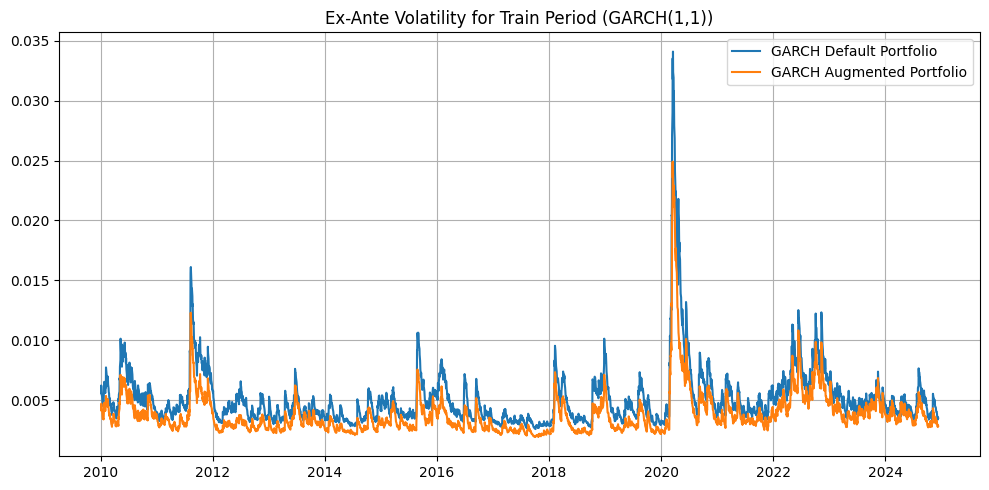

In [100]:
# Plotting GARCH vols
plt.figure(figsize=(10, 5))
plt.plot(vol_default_garch_train, label='GARCH Default Portfolio', linestyle='-')
plt.plot(vol_augmented_garch_train, label='GARCH Augmented Portfolio', linestyle='-')
plt.title("Ex-Ante Volatility for Train Period (GARCH(1,1))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2-B) GARCH (testing set)

In [101]:
model_default_test = arch_model(ret_default_test, vol='Garch', p=1, q=1) # fit it both for default & optimized ptf (testing set)
garch_default_fit_test = model_default_test.fit()

model_augmented_test = arch_model(ret_augmented_test, vol='Garch', p=1, q=1)
garch_augmented_fit_test = model_augmented_test.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1365563425601.7317
Iteration:      2,   Func. Count:     19,   Neg. LLF: -15470.684303193384
Optimization terminated successfully    (Exit mode 0)
            Current function value: -15470.684304129543
            Iterations: 6
            Function evaluations: 19
            Gradient evaluations: 2
Iteration:      1,   Func. Count:      6,   Neg. LLF: 90127736305122.25
Iteration:      2,   Func. Count:     20,   Neg. LLF: 5.935708077430448e+18
Iteration:      3,   Func. Count:     34,   Neg. LLF: -16038.480113116035
Inequality constraints incompatible    (Exit mode 4)
            Current function value: -16038.480092535774
            Iterations: 4
            Function evaluations: 34
            Gradient evaluations: 3


/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.849e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.289e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:768: ConvergenceWa

In [102]:
# GARCH conditional vol estimates
vol_default_garch_test = garch_default_fit_test.conditional_volatility
vol_augmented_garch_test = garch_augmented_fit_test.conditional_volatility

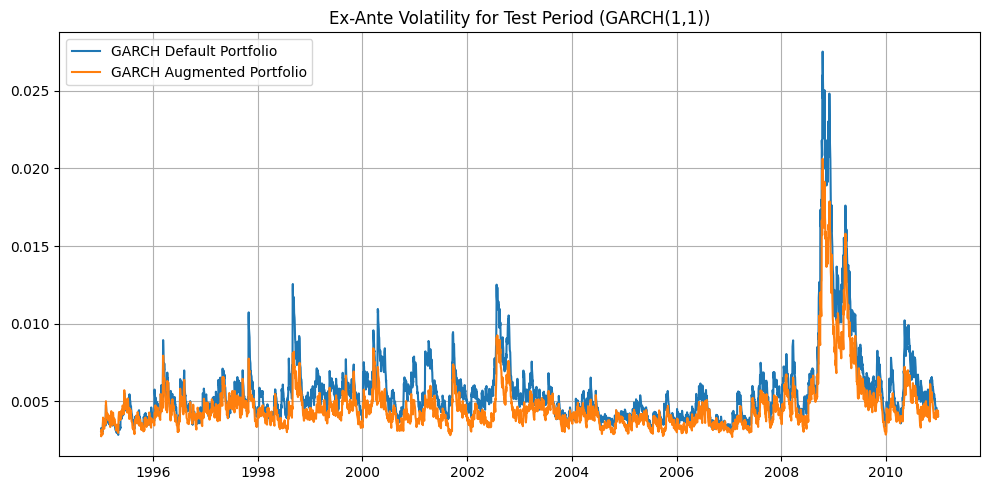

In [103]:
# Plotting GARCH vols
plt.figure(figsize=(10, 5))
plt.plot(vol_default_garch_test, label='GARCH Default Portfolio', linestyle='-')
plt.plot(vol_augmented_garch_test, label='GARCH Augmented Portfolio', linestyle='-')
plt.title("Ex-Ante Volatility for Test Period (GARCH(1,1))")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Same remark for GARCH(1,1): higher peaks of vol for the augmented ptf, which is logical..

In [104]:
# If we compute the historical data with a window of 1 yr (252 days)
window = 252
vol_default_real = ret_default_test.rolling(window).std()
vol_augmented_real = ret_augmented_test.rolling(window).std()
vol_default_real = vol_default_real.dropna()
vol_augmented_real = vol_augmented_real.dropna()

In [105]:
vol_default_garch = vol_default_garch_test.loc[vol_default_real.index]
vol_augmented_garch = vol_augmented_garch_test.loc[vol_augmented_real.index]
vol_default_ewma = vol_default_test_ewma.loc[vol_default_real.index]
vol_augmented_ewma = vol_augmented_test_ewma.loc[vol_augmented_real.index]

1st criteria for GARCH: average bias

In [106]:
# Normalize returns using the EWMA conditional volatility
z_scores_default_garch = ret_default_test['Return'] / vol_default_garch
z_scores_augmented_garch = ret_augmented_test['Return'] / vol_augmented_garch

# Calculate the standard deviation of the z-scores
stdev_z_default = np.std(z_scores_default_garch)
stdev_z_augmented = np.std(z_scores_augmented_garch)

# Number of observations (out-of-sample period length)
M = len(z_scores_default_garch)

# Compute standard error of the standard deviation
se_default = stdev_z_default * (1 / np.sqrt(2 * M))
se_augmented = stdev_z_augmented * (1 / np.sqrt(2 * M))

# Confidence intervals for stdev(z)
ci_default = (stdev_z_default - 2 * se_default, stdev_z_default + 2 * se_default)
ci_augmented = (stdev_z_augmented - 2 * se_augmented, stdev_z_augmented + 2 * se_augmented)

# Display results
print("Default Portfolio:")
print(f"Standard deviation of z-scores: {stdev_z_default:.4f}")
print(f"95% CI: {ci_default[0]:.4f} to {ci_default[1]:.4f}")

print("Augmented Portfolio:")
print(f"Standard deviation of z-scores: {stdev_z_augmented:.4f}")
print(f"95% CI: {ci_augmented[0]:.4f} to {ci_augmented[1]:.4f}")

Default Portfolio:
Standard deviation of z-scores: 0.9956
95% CI: 0.9734 to 1.0178
Augmented Portfolio:
Standard deviation of z-scores: 0.9520
95% CI: 0.9308 to 0.9732


2nd criteria for GARCH: long term bias

In [107]:
mrad_default_garch = compute_mrad(z_scores_default_garch)
mrad_augmented_garch = compute_mrad(z_scores_augmented_garch)

print("GARCH - Default Portfolio MRAD:", round(mrad_default_garch, 4))
print("GARCH - Augmented Portfolio MRAD:", round(mrad_augmented_garch, 4))

GARCH - Default Portfolio MRAD: 0.0517
GARCH - Augmented Portfolio MRAD: 0.0736


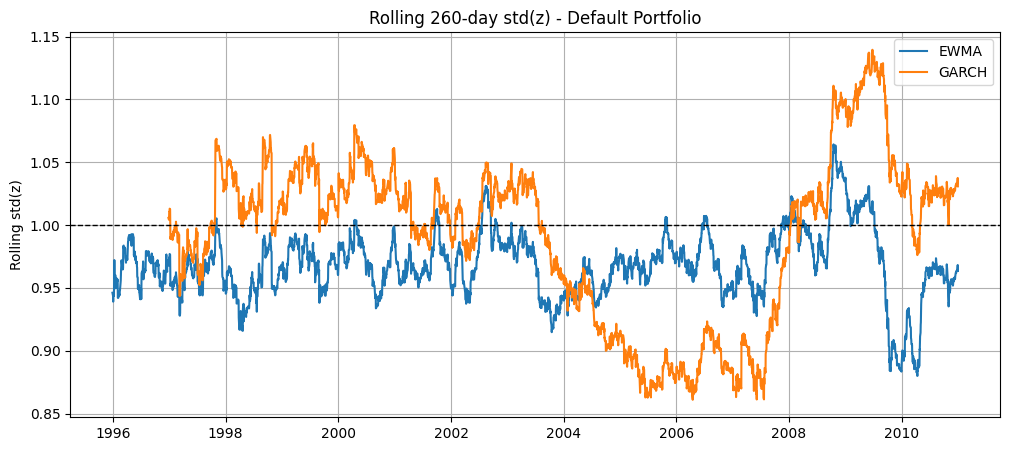

In [108]:
# Plotting the rolling std dev of the z score for the 2: both EWMA & GARCH (default ptf)

rolling_std_default_ewma = z_scores_default_ewma.rolling(window=252).std()
rolling_std_default_garch = z_scores_default_garch.rolling(window=252).std()
plt.figure(figsize=(12, 5))
plt.plot(rolling_std_default_ewma, label="EWMA")
plt.plot(rolling_std_default_garch, label="GARCH")
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title("Rolling 260-day std(z) - Default Portfolio")
plt.ylabel("Rolling std(z)")
plt.legend()
plt.grid(True)
plt.show()

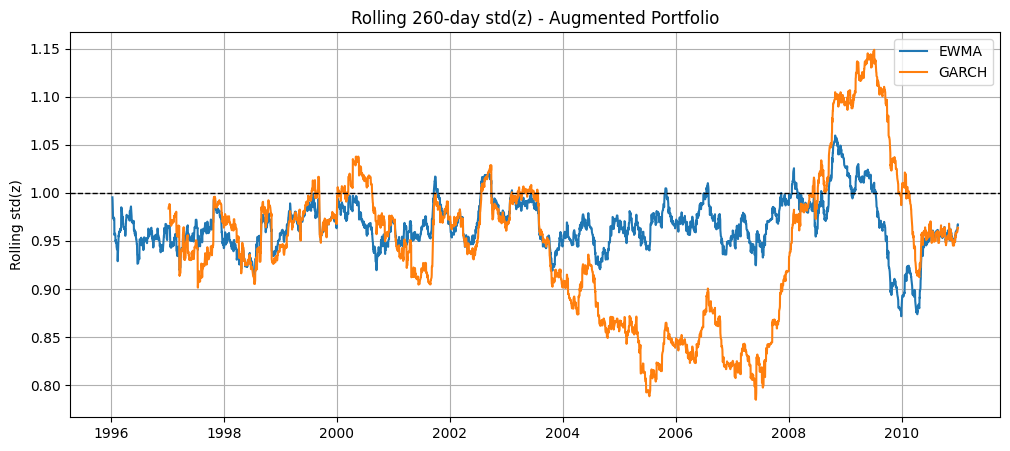

In [109]:
# Same for augmented ptf:
rolling_std_augmented_ewma = z_scores_augmented_ewma.rolling(window=260).std()
rolling_std_augmented_garch = z_scores_augmented_garch.rolling(window=260).std()

plt.figure(figsize=(12, 5))
plt.plot(rolling_std_augmented_ewma, label="EWMA")
plt.plot(rolling_std_augmented_garch, label="GARCH")
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title("Rolling 260-day std(z) - Augmented Portfolio")
plt.ylabel("Rolling std(z)")
plt.legend()
plt.grid(True)
plt.show()

<b><u>Comments:</b></u>

EWMA:
- <u>Default Portfolio:</u>
- Standard deviation of z-scores: 0.9682
- <u>Augmented Portfolio:</u>
- Standard deviation of z-scores: 0.9689

- EWMA - Default Portfolio MRAD: 0.0351
- EWMA - Augmented Portfolio MRAD: 0.0376

GARCH:
- <u>Default Portfolio:</u>
- Standard deviation of z-scores: 0.9956
- <u>Augmented Portfolio:</u>
- Standard deviation of z-scores: 0.9520

- GARCH - Default Portfolio MRAD: 0.0517
- GARCH - Augmented Portfolio MRAD: 0.0736

- Based on criteria 1 (avge biais) -> would select GARCH(1,1) model: mean of std deviation of z-scores closer to 1 than EWMA
- Based on criteria 2 (long term bias) -> would select EWMA model: smaller MRAD than GARCH for both default & augmented ptf
- And also in the graph just above (rolling std of z-score): smaller variations in rolling std of z-score for EWMA, notably in periods of crisis (2007/2008 & 2020-Covid for instance)
- So would select EWMA(0.94) for our analysis.

In [110]:
# So ex-ante vol on 11-Dec-2024 (extracting it from the training set) -> to answer last part of RQ1 (& working with EWMA only as of now)
vol_date = '2024-12-11'
vol_default_11dec = vol_default_train.loc[vol_date]
vol_augmented_11dec = vol_augmented_train.loc[vol_date]
print(f"Default portfolio volatility on {vol_date}: {vol_default_11dec:.4%}")
print(f"Augmented portfolio volatility on {vol_date}: {vol_augmented_11dec:.4%}")

Default portfolio volatility on 2024-12-11: 0.3441%
Augmented portfolio volatility on 2024-12-11: 0.2724%


## <u>RQ 2 – downside risk :
### What are the ex-ante VaRs of the augmented & default portfolios on Wednesday 11-Dec-2024 close and how does this compare against the course of these ex-ante VaRs over time ?

#### 1-Parametric VaR

- Parametric VaR assumes normality and uses EWMA volatility (λ = 0.94) to capture recent changes in market risk.
- Does not require any rolling window computations for every single data point.
- So more useful for ptf exposed to more short-term fluctuations
- Works well when vol is smooth and when we don't have extreme spikes/clusters of vol.

In [111]:
# So here we work again with the full sample (from 1995 to 2024)
ret_default= returns @ w_default
ret_augmented = returns @ w_augmented

ret_default = pd.DataFrame(ret_default, columns=['Return'])
ret_augmented = pd.DataFrame(ret_augmented, columns=['Return'])

vol_default=ewma_volatility(ret_default) # EWMA Vol for the default portfolio
vol_augmented=ewma_volatility(ret_augmented) # EWMA Vol for the augmented portfolio

In [112]:
# Here we work with full sample again:
# So first we consider the regulatory 1-day 95% VaR
z_95 = -1.645

# Calculate parametric VaR for both portfolios
var_default_param = z_95 * vol_default
var_augmented_param = z_95 * vol_augmented

# Extract the VaR value for 11-Dec-2024
var_default_11dec = var_default_param.loc['2024-12-11']
var_augmented_11dec = var_augmented_param.loc['2024-12-11']

# Display results
print(f"Parametric 1-day 95% VaR on 11-Dec-2024:")
print(f"  - Default Portfolio:   {var_default_11dec:.4%}")
print(f"  - Augmented Portfolio: {var_augmented_11dec:.4%}")

Parametric 1-day 95% VaR on 11-Dec-2024:
  - Default Portfolio:   -0.5661%
  - Augmented Portfolio: -0.4482%


#### 2-Historical VaR

- Non-parametric and based on the 5th percentile of a 252-day rolling window of actual returns.
- Makes no assumptions about the distribution of returns
- Can handle better non-linear and fat-tailed distributions (often observed in financial markets during periods of extreme vol).
- Reflects real mkt conditions.
- Purely based on historical data.

In [113]:
# Rolling window size (252 trading days ≈ 1 year)
window = 252
quantile = 0.05

# Calculate non-parametric (historical) VaR using rolling 5th percentile
var_default_hist = ret_default.rolling(window).quantile(quantile)
var_augmented_hist = ret_augmented.rolling(window).quantile(quantile)

# Extract values for 11-Dec-2024
var_default_hist_11dec = var_default_hist.loc['2024-12-11'].iloc[0] # Access the scalar value using .iloc[0]
var_augmented_hist_11dec = var_augmented_hist.loc['2024-12-11'].iloc[0] # Access the scalar value using .iloc[0]

# Display results
print(f"Non-Parametric (Historical) 1-day 95% VaR on 11-Dec-2024:")
print(f"  - Default Portfolio:   {var_default_hist_11dec:.4%}")
print(f"  - Augmented Portfolio: {var_augmented_hist_11dec:.4%}")

Non-Parametric (Historical) 1-day 95% VaR on 11-Dec-2024:
  - Default Portfolio:   -0.6657%
  - Augmented Portfolio: -0.5531%


In [114]:
# Align lengths by dropping NaNs
var_default_combined = pd.DataFrame({
    'Parametric': var_default_param,
    'Historical': var_default_hist['Return'] # Extract the 'Return' column as a Series
}).dropna()

var_augmented_combined = pd.DataFrame({
    'Parametric': var_augmented_param,
    'Historical': var_augmented_hist['Return'] # Extract the 'Return' column as a Series
}).dropna()

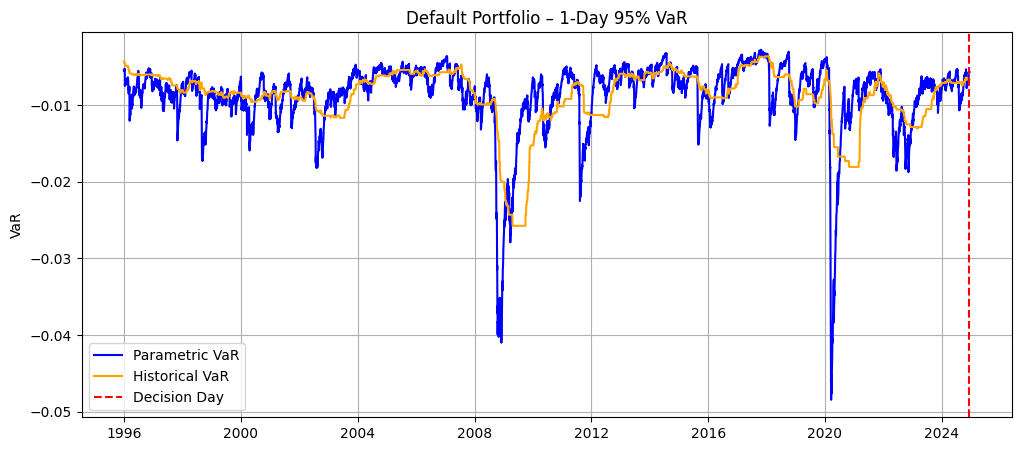

In [115]:
# Plot Default Portfolio VaR
plt.figure(figsize=(12, 5))
plt.plot(var_default_combined['Parametric'], label='Parametric VaR', color='blue')
plt.plot(var_default_combined['Historical'], label='Historical VaR', color='orange')
plt.axvline(pd.to_datetime('2024-12-11'), color='red', linestyle='--', label='Decision Day')
plt.title('Default Portfolio – 1-Day 95% VaR')
plt.ylabel('VaR')
plt.legend()
plt.grid(True)
plt.show()

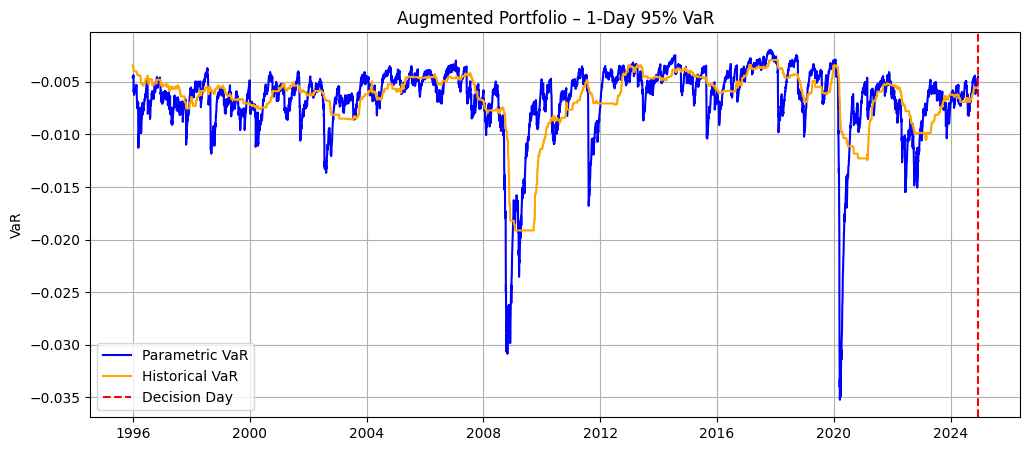

In [116]:
# Plot Augmented Portfolio VaR
plt.figure(figsize=(12, 5))
plt.plot(var_augmented_combined['Parametric'], label='Parametric VaR', color='blue')
plt.plot(var_augmented_combined['Historical'], label='Historical VaR', color='orange')
plt.axvline(pd.to_datetime('2024-12-11'), color='red', linestyle='--', label='Decision Day')
plt.title('Augmented Portfolio – 1-Day 95% VaR')
plt.ylabel('VaR')
plt.legend()
plt.grid(True)
plt.show()

<b><u>Comments:</b></u>
- On 11-Dec-2024, both VaR models indicate that the augmented portfolio carries lower downside risk than the default portfolio, both its parametric and historical VaR estimates are less negative than those of the default portfolio on 11-Dec-2024. This aligns with its more defensive allocation. Over time, the augmented portfolio consistently shows lower VaR estimates across both methods.
- For both default & augmented ptf, seems like parametric VaR  is more reactive to the recent changes in vol. Shows also higher peaks during high vol period than historical VaR (in 2008 for instance or during Covid) -> because EWMA puts more weight on recent fluctuations.
- Historical VaR reacts way slowly to new vol informations, and it kind of smoothes the vol peaks during crisis (ex:2008).

Criteria to choose VaR model: number of exceedances

In [117]:
# VaR exceedances criteria:
def compute_exceedances(returns_df, var_input):
    returns = returns_df['Return']

    if isinstance(var_input, pd.DataFrame):
        if 'Return' in var_input.columns:
            var_series = var_input['Return']
        else:
            var_series = var_input.iloc[:, 0]
    else:
        var_series = var_input

    returns, var_series = returns.align(var_series, join='inner')
    exceedances = returns < var_series
    return exceedances

In [118]:
exceed_default_param = compute_exceedances(ret_default, var_default_param)
exceed_default_hist = compute_exceedances(ret_default, var_default_hist)

exceed_augmented_param = compute_exceedances(ret_augmented, var_augmented_param)
exceed_augmented_hist = compute_exceedances(ret_augmented, var_augmented_hist)

In [119]:
def exceedances_per_year(exceedances):
    exceed_df = exceedances.to_frame('exceed')
    exceed_df['year'] = exceed_df.index.year
    return exceed_df.groupby('year')['exceed'].sum()

In [120]:
total_years = ret_default.index.year.nunique()
exceed_default_param_avg = exceed_default_param.sum() / total_years
exceed_default_hist_avg = exceed_default_hist.sum() / total_years

exceed_augmented_param_avg = exceed_augmented_param.sum() / total_years
exceed_augmented_hist_avg = exceed_augmented_hist.sum() / total_years

print(f"\nExceedances per year (Average over full period):")
print(f"Default - Parametric: {exceed_default_param_avg:.2f}")
print(f"Default - Historical: {exceed_default_hist_avg:.2f}")
print(f"Augmented - Parametric: {exceed_augmented_param_avg:.2f}")
print(f"Augmented - Historical: {exceed_augmented_hist_avg:.2f}")


Exceedances per year (Average over full period):
Default - Parametric: 11.60
Default - Historical: 13.43
Augmented - Parametric: 11.40
Augmented - Historical: 13.53


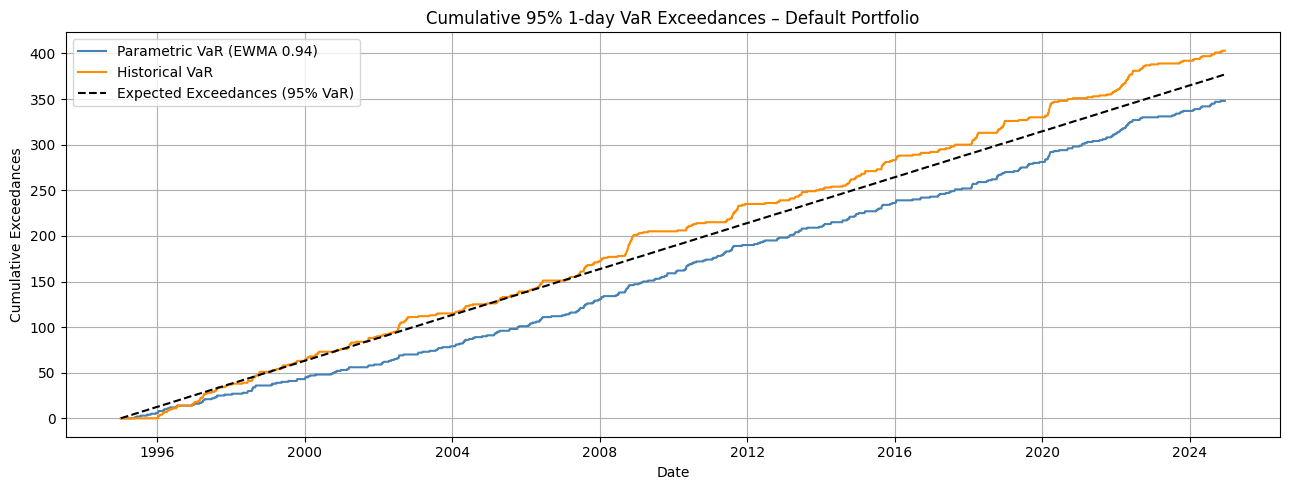

In [121]:
# Graph / exceedance for default ptf:

# Step 1 – Compute cumulative exceedances
cumul_exceed_default_param = exceed_default_param.cumsum()
cumul_exceed_default_hist = exceed_default_hist.cumsum()

# Step 2 – Compute expected exceedance path
# Expected exceedance rate: 5% of days
expected_exceedances = pd.Series(
    data=range(1, len(cumul_exceed_default_param) + 1),
    index=cumul_exceed_default_param.index
) * 0.05  # 5% exceedance

# Step 3 – Plot
plt.figure(figsize=(13, 5))
plt.plot(cumul_exceed_default_param, label='Parametric VaR (EWMA 0.94)', color='steelblue')
plt.plot(cumul_exceed_default_hist, label='Historical VaR', color='darkorange')
plt.plot(expected_exceedances, label='Expected Exceedances (95% VaR)', linestyle='--', color='black')

plt.title("Cumulative 95% 1-day VaR Exceedances – Default Portfolio")
plt.ylabel("Cumulative Exceedances")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

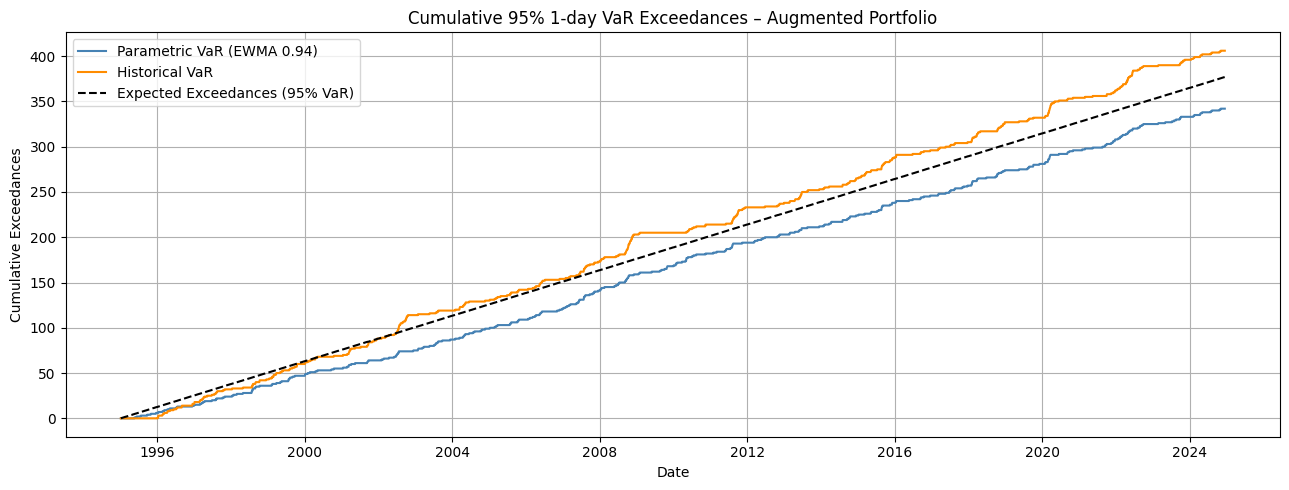

In [122]:
# Graph for default ptf:

# Step 1 – Compute cumulative exceedances
cumul_exceed_augmented_param = exceed_augmented_param.cumsum()
cumul_exceed_augmented_hist = exceed_augmented_hist.cumsum()

# Step 2 – Compute expected exceedance path
# Expected exceedance rate: 5% of days
expected_exceedances = pd.Series(
    data=range(1, len(cumul_exceed_augmented_param) + 1),
    index=cumul_exceed_augmented_param.index
) * 0.05  # 5% exceedance

# Step 3 – Plot
plt.figure(figsize=(13, 5))
plt.plot(cumul_exceed_augmented_param, label='Parametric VaR (EWMA 0.94)', color='steelblue')
plt.plot(cumul_exceed_augmented_hist, label='Historical VaR', color='darkorange')
plt.plot(expected_exceedances, label='Expected Exceedances (95% VaR)', linestyle='--', color='black')

plt.title("Cumulative 95% 1-day VaR Exceedances – Augmented Portfolio")
plt.ylabel("Cumulative Exceedances")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [123]:
# Expected number of exceedances per year at 95% confidence
expected_exceedances_per_year = 252 * 0.05  # = 12.6 ≈ 13

# Period masks
mask_gfc = (ret_default.index >= '2007-01-01') & (ret_default.index <= '2008-12-31')
mask_covid = (ret_default.index >= '2020-02-01') & (ret_default.index <= '2020-12-31')

# Total trading days in those periods
days_gfc = mask_gfc.sum()
days_covid = mask_covid.sum()

# Years spanned
years_gfc = 2
years_covid = 1

# Exceedances during those periods
gfc_param = exceed_default_param[mask_gfc].sum()
gfc_hist = exceed_default_hist[mask_gfc].sum()

covid_param = exceed_default_param[mask_covid].sum()
covid_hist = exceed_default_hist[mask_covid].sum()

# Annualized exceedances (per annum)
gfc_param_annual = gfc_param / years_gfc
gfc_hist_annual = gfc_hist / years_gfc

covid_param_annual = covid_param / years_covid
covid_hist_annual = covid_hist / years_covid

# Full-period averages (from earlier)
avg_param = exceed_default_param.sum() / ret_default.index.year.nunique()
avg_hist = exceed_default_hist.sum() / ret_default.index.year.nunique()

# Create summary DataFrame
import pandas as pd

summary_table = pd.DataFrame({
    "Expected": [expected_exceedances_per_year]*3,
    "Parametric (0.94)": [avg_param, gfc_param_annual, covid_param_annual],
    "Historical (HSim)": [avg_hist, gfc_hist_annual, covid_hist_annual]
}, index=["Full Sample (avg p.a.)", "GFC 2007–2008", "COVID 2020"])


# Display the summary table as plain text
print("\n Exceedances per annum (95% 1-day VaR – Default Portfolio):\n")
print(summary_table.round(1).to_string())


 Exceedances per annum (95% 1-day VaR – Default Portfolio):

                        Expected  Parametric (0.94)  Historical (HSim)
Full Sample (avg p.a.)      12.6               11.6               13.4
GFC 2007–2008               12.6               17.0               25.0
COVID 2020                  12.6               14.0               19.0


In [124]:
# Period masks for augmented portfolio
mask_gfc_aug = (ret_augmented.index >= '2007-01-01') & (ret_augmented.index <= '2008-12-31')
mask_covid_aug = (ret_augmented.index >= '2020-02-01') & (ret_augmented.index <= '2020-12-31')

# Total trading days in those periods
days_gfc_aug = mask_gfc_aug.sum()
days_covid_aug = mask_covid_aug.sum()

# Years spanned
years_gfc = 2
years_covid = 1

# Exceedances during those periods
gfc_param_aug = exceed_augmented_param[mask_gfc_aug].sum()
gfc_hist_aug = exceed_augmented_hist[mask_gfc_aug].sum()

covid_param_aug = exceed_augmented_param[mask_covid_aug].sum()
covid_hist_aug = exceed_augmented_hist[mask_covid_aug].sum()

# Annualized exceedances (per annum)
gfc_param_annual_aug = gfc_param_aug / years_gfc
gfc_hist_annual_aug = gfc_hist_aug / years_gfc

covid_param_annual_aug = covid_param_aug / years_covid
covid_hist_annual_aug = covid_hist_aug / years_covid

# Full-period averages
avg_param_aug = exceed_augmented_param.sum() / ret_augmented.index.year.nunique()
avg_hist_aug = exceed_augmented_hist.sum() / ret_augmented.index.year.nunique()

# Create summary DataFrame
summary_table_aug = pd.DataFrame({
    "Expected": [expected_exceedances_per_year]*3,
    "Parametric (0.94)": [avg_param_aug, gfc_param_annual_aug, covid_param_annual_aug],
    "Historical (HSim)": [avg_hist_aug, gfc_hist_annual_aug, covid_hist_annual_aug]
}, index=["Full Sample (avg p.a.)", "GFC 2007–2008", "COVID 2020"])

# Display the table
print("\nExceedances per annum (95% 1-day VaR – Augmented Portfolio):\n")
print(summary_table_aug.round(1).to_string())



Exceedances per annum (95% 1-day VaR – Augmented Portfolio):

                        Expected  Parametric (0.94)  Historical (HSim)
Full Sample (avg p.a.)      12.6               11.4               13.5
GFC 2007–2008               12.6               19.0               24.5
COVID 2020                  12.6               13.0               20.0


<b><u>Comments:</b></u>
- Based on the first grzaphs (1 day 95% VaR, we observe that parametric VaR is more reactive to big changes to recent changes, while historical king of smoothes in crisis periods.
- Based on exceedances per annum, historical VaR is actually closer to expected (5% of days) on the whole sample, but it clearly does worse than parametric during the two major crisis of the sample (2007-2008 and covid in 2020).
- Would choose paramteric VaR based on this.

In [125]:
# So reminder to answer the RQ2:
print(f"Parametric 1-day 95% VaR on 11-Dec-2024:")
print(f"  - Default Portfolio:   {var_default_11dec:.4%}")
print(f"  - Augmented Portfolio: {var_augmented_11dec:.4%}")

Parametric 1-day 95% VaR on 11-Dec-2024:
  - Default Portfolio:   -0.5661%
  - Augmented Portfolio: -0.4482%


## <u>RQ 3 – risk decomposition :
### What are the ex-ante risk decompositions of the augmented & default portfolios on Wednesday 11-Dec-2024 close and how does this compare against the course of these decompositions over time ? ?

#### 1-252 day classic rolling window

- We first computed the risk contribution of each asset class over time with a 1 year rolling window -> 252 days

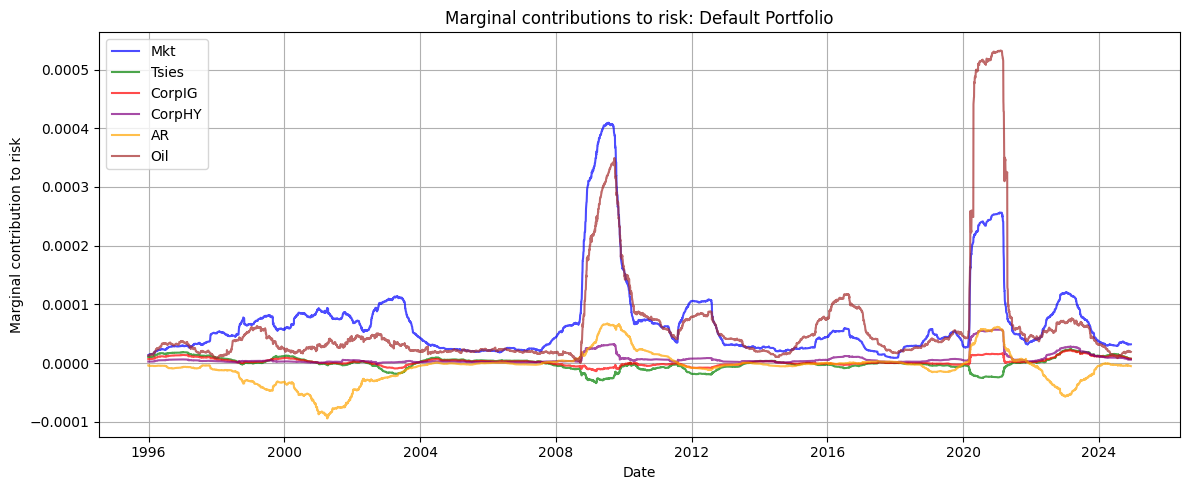

In [126]:
window = 252

returns_default = ret_default
returns_augmented = ret_augmented
marginal_contrib_default_all = []

# Marginal contrib to risk being cov.W
for i in range(window, len(df)):
    cov_matrix_window = returns.iloc[i-window:i].cov()

    marginal_contrib_default = np.dot(cov_matrix_window, w_default)
    marginal_contrib_default_all.append(marginal_contrib_default)

marginal_contrib_default_df = pd.DataFrame(marginal_contrib_default_all,
                                            columns=df.columns[0:len(w_default)],
                                            index=df.index[window:])

colors1 = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

for i, col in enumerate(marginal_contrib_default_df.columns):
    axes.plot(marginal_contrib_default_df.index, marginal_contrib_default_df[col],
              label=f'{col}', alpha=0.7, color=colors1[i])
axes.set_xlabel('Date')
axes.set_ylabel('Marginal contribution to risk')
axes.set_title('Marginal contributions to risk: Default Portfolio')
axes.legend(loc='upper left')
axes.grid(True)
plt.tight_layout()
plt.show()

<b><u>Comments:</b></u>
- In major crisis (2008 & COVID), mkt was the biggest contributor to risk (and it was throughout the whole period by the way)
- Except in 2020 (the period when we saw oil price extremely volatile, and even going negative when we preprocessed data)
- We also see that AR acts as a sort of risk hedge, as it has a negative risk contribution most of the time

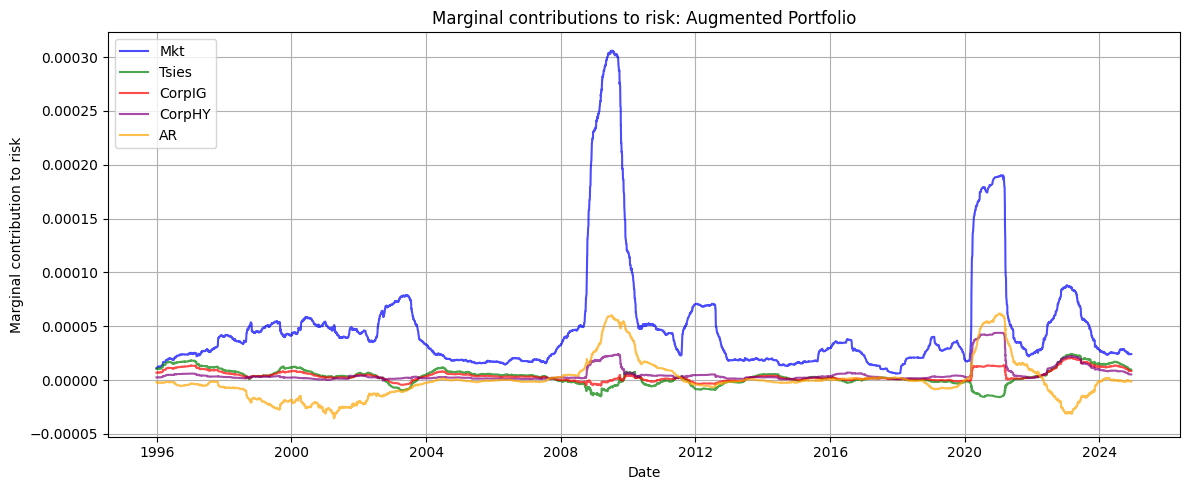

In [127]:
# For optimized ptf
# Here we had  to remove the oil column otherwise we kept an oil exposure
returns_default = ret_default
returns_augmented = ret_augmented
marginal_contrib_augmented_no_oil_all = []

w_augmented_no_oil = np.array([0.40, 0.40, 0.00, 0.05, 0.15])  # we exclude the oil weight/returns

for i in range(window, len(df)):
    returns_no_oil = returns.iloc[i-window:i, :5] # Selecting the first 5 asset classes only
    cov_matrix_window = returns_no_oil.cov()

    marginal_contrib_augmented_no_oil = np.dot(cov_matrix_window, w_augmented_no_oil)
    marginal_contrib_augmented_no_oil_all.append(marginal_contrib_augmented_no_oil)

marginal_contrib_augmented_no_oil_df = pd.DataFrame(marginal_contrib_augmented_no_oil_all,
                                                     columns=df.columns[0:len(w_augmented_no_oil)],
                                                     index=df.index[window:])

colors = ['blue', 'green', 'red', 'purple', 'orange']
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

for i, col in enumerate(marginal_contrib_augmented_no_oil_df.columns):
    axes.plot(marginal_contrib_augmented_no_oil_df.index, marginal_contrib_augmented_no_oil_df[col],
              label=f'{col}', alpha=0.7, color=colors[i])

axes.set_xlabel('Date')
axes.set_ylabel('Marginal contribution to risk')
axes.set_title('Marginal contributions to risk: Augmented Portfolio')
axes.legend(loc='upper left')
axes.grid(True)
plt.tight_layout()
plt.show()

<b><u>Comment:</b></u>
- Mkt still is th biggest risk contributor
- And same hedge for AR

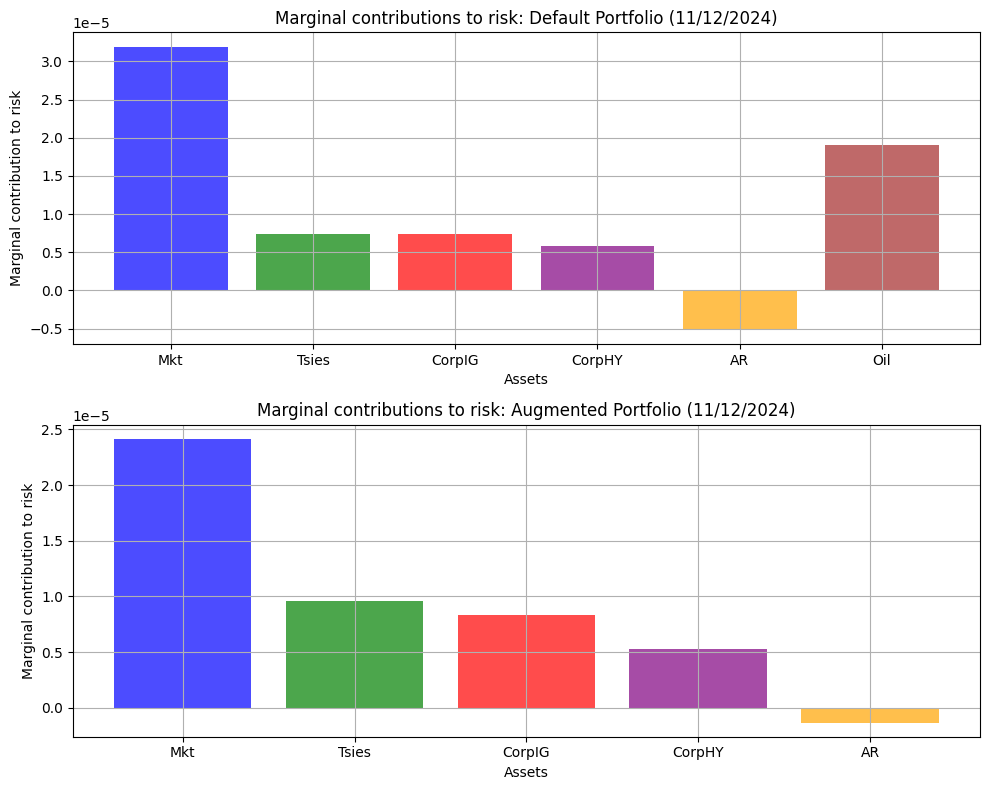

In [128]:
# And only for 2024-12-11
date_target = pd.to_datetime('2024-12-11')
marginal_contrib_default_11dec = marginal_contrib_default_df.loc[date_target]
marginal_contrib_augmented_11dec = marginal_contrib_augmented_no_oil_df.loc[date_target]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].bar(marginal_contrib_default_11dec.index, marginal_contrib_default_11dec,
            color=colors1[:len(marginal_contrib_default_11dec)], alpha=0.7)
axes[0].set_xlabel('Assets')
axes[0].set_ylabel('Marginal contribution to risk')
axes[0].set_title('Marginal contributions to risk: Default Portfolio (11/12/2024)')
axes[0].grid(True)

axes[1].bar(marginal_contrib_augmented_11dec.index, marginal_contrib_augmented_11dec,
            color=colors1[:len(marginal_contrib_augmented_11dec)], alpha=0.7)
axes[1].set_xlabel('Assets')
axes[1].set_ylabel('Marginal contribution to risk')
axes[1].set_title('Marginal contributions to risk: Augmented Portfolio (11/12/2024)')
axes[1].grid(True)

plt.tight_layout()
plt.show()


<b><u>Comments:</b></u>
- Mkt contributes the most to risk, by far for both ptf
- Oil is the second contributor for default ptf (while only being 5% of it !)
- The fixed income part (Treasuries, CorpIG and HY) contributes way less to the ptf risk, be it for the default or the optimized ptf
- AR acts as a "hedge": negative contrib to ptf risk both for default & augmented ptf

#### 2-Exponential decrease over time

Other idea: to take more into account RQ1 & RQ2, what we can do = we add an exponential decrease lambda (0.94), to keep the logic of EWMA

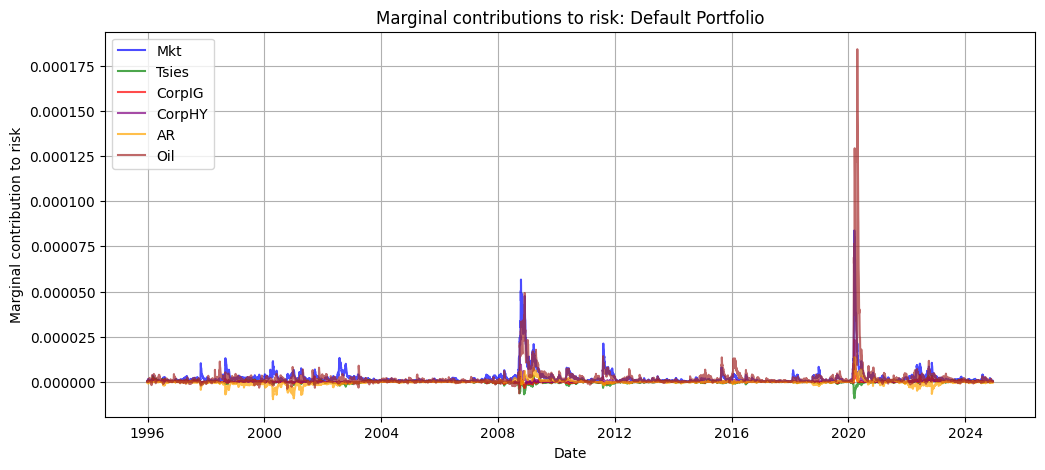

In [129]:
lambda_ = 0.94
window = 252

w_default = np.array([0.50, 0.30, 0.05, 0.00, 0.10, 0.05])
w_augmented_no_oil = np.array([0.40, 0.40, 0.00, 0.05, 0.15])

# --- Default Portfolio (with oil) ---
marginal_contrib_default_all = []

for i in range(window, len(df)):
    returns_window = returns.iloc[i - window:i]
    exp_weights = (lambda_ ** np.arange(window - 1, -1, -1))[:, np.newaxis]
    weighted_returns = returns_window * exp_weights
    cov_matrix_window = weighted_returns.cov()
    marginal_contrib_default = np.dot(cov_matrix_window, w_default)
    marginal_contrib_default_all.append(marginal_contrib_default)

marginal_contrib_default_df = pd.DataFrame(marginal_contrib_default_all,
                                            columns=df.columns[0:len(w_default)],
                                            index=df.index[window:])


# Default Portfolio Plot
plt.figure(figsize=(12, 5))
for i, col in enumerate(marginal_contrib_default_df.columns):
    plt.plot(marginal_contrib_default_df.index, marginal_contrib_default_df[col],
                 label=f'{col}', alpha=0.7, color=colors1[i])

plt.xlabel('Date')
plt.ylabel('Marginal contribution to risk')
plt.title('Marginal contributions to risk: Default Portfolio')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


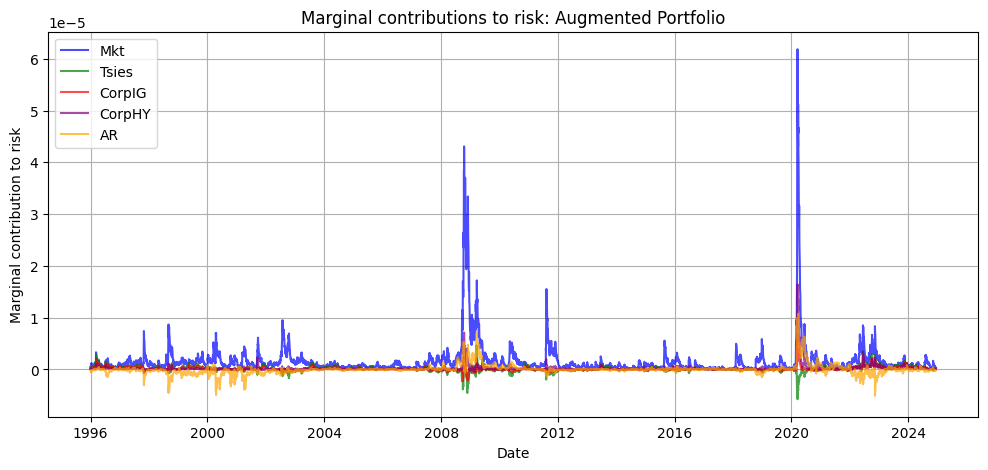

In [130]:
# --- Augmented Portfolio (without oil) ---
marginal_contrib_augmented_no_oil_all = []

for i in range(window, len(df)):
    returns_window = returns.iloc[i - window:i]
    exp_weights = (lambda_ ** np.arange(window - 1, -1, -1))[:, np.newaxis]
    weighted_returns = returns_window * exp_weights
    cov_matrix_window = weighted_returns.cov()

    # Select relevant part of covariance matrix (excluding Oil)
    cov_matrix_window_no_oil = cov_matrix_window.iloc[:5, :5]
    marginal_contrib_augmented_no_oil = np.dot(cov_matrix_window_no_oil, w_augmented_no_oil)
    marginal_contrib_augmented_no_oil_all.append(marginal_contrib_augmented_no_oil)

marginal_contrib_augmented_no_oil_df = pd.DataFrame(marginal_contrib_augmented_no_oil_all,
                                                     columns=df.columns[0:len(w_augmented_no_oil)],
                                                     index=df.index[window:])

# Augmented Portfolio Plot
plt.figure(figsize=(12, 5))
for i, col in enumerate(marginal_contrib_augmented_no_oil_df.columns):
    plt.plot(marginal_contrib_augmented_no_oil_df.index, marginal_contrib_augmented_no_oil_df[col],
                 label=f'{col}', alpha=0.7, color=colors[i])

plt.xlabel('Date')
plt.ylabel('Marginal contribution to risk')
plt.title('Marginal contributions to risk: Augmented Portfolio')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

- But way less visual than with classic 252 rolling window

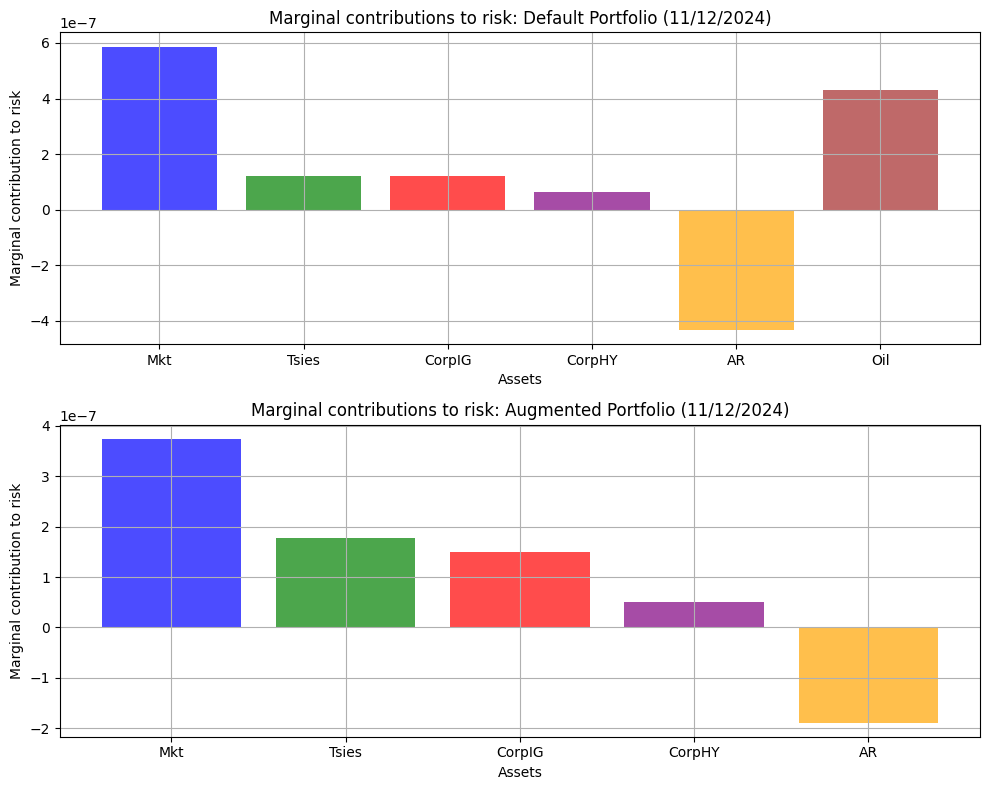

In [131]:
# And only for 2024-12-11 with the lambda
date_target = pd.to_datetime('2024-12-11')
marginal_contrib_default_11dec = marginal_contrib_default_df.loc[date_target]
marginal_contrib_augmented_11dec = marginal_contrib_augmented_no_oil_df.loc[date_target]

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].bar(marginal_contrib_default_11dec.index, marginal_contrib_default_11dec,
            color=colors1[:len(marginal_contrib_default_11dec)], alpha=0.7)
axes[0].set_xlabel('Assets')
axes[0].set_ylabel('Marginal contribution to risk')
axes[0].set_title('Marginal contributions to risk: Default Portfolio (11/12/2024)')
axes[0].grid(True)

axes[1].bar(marginal_contrib_augmented_11dec.index, marginal_contrib_augmented_11dec,
            color=colors1[:len(marginal_contrib_augmented_11dec)], alpha=0.7)
axes[1].set_xlabel('Assets')
axes[1].set_ylabel('Marginal contribution to risk')
axes[1].set_title('Marginal contributions to risk: Augmented Portfolio (11/12/2024)')
axes[1].grid(True)

plt.tight_layout()
plt.show()


Which one to choose ?

## <u>RQ 4 – tail risk
### As per Wednesday 11-Dec-2024 close, how do the tail risks of the default portfolio change after implementing the active positions ?

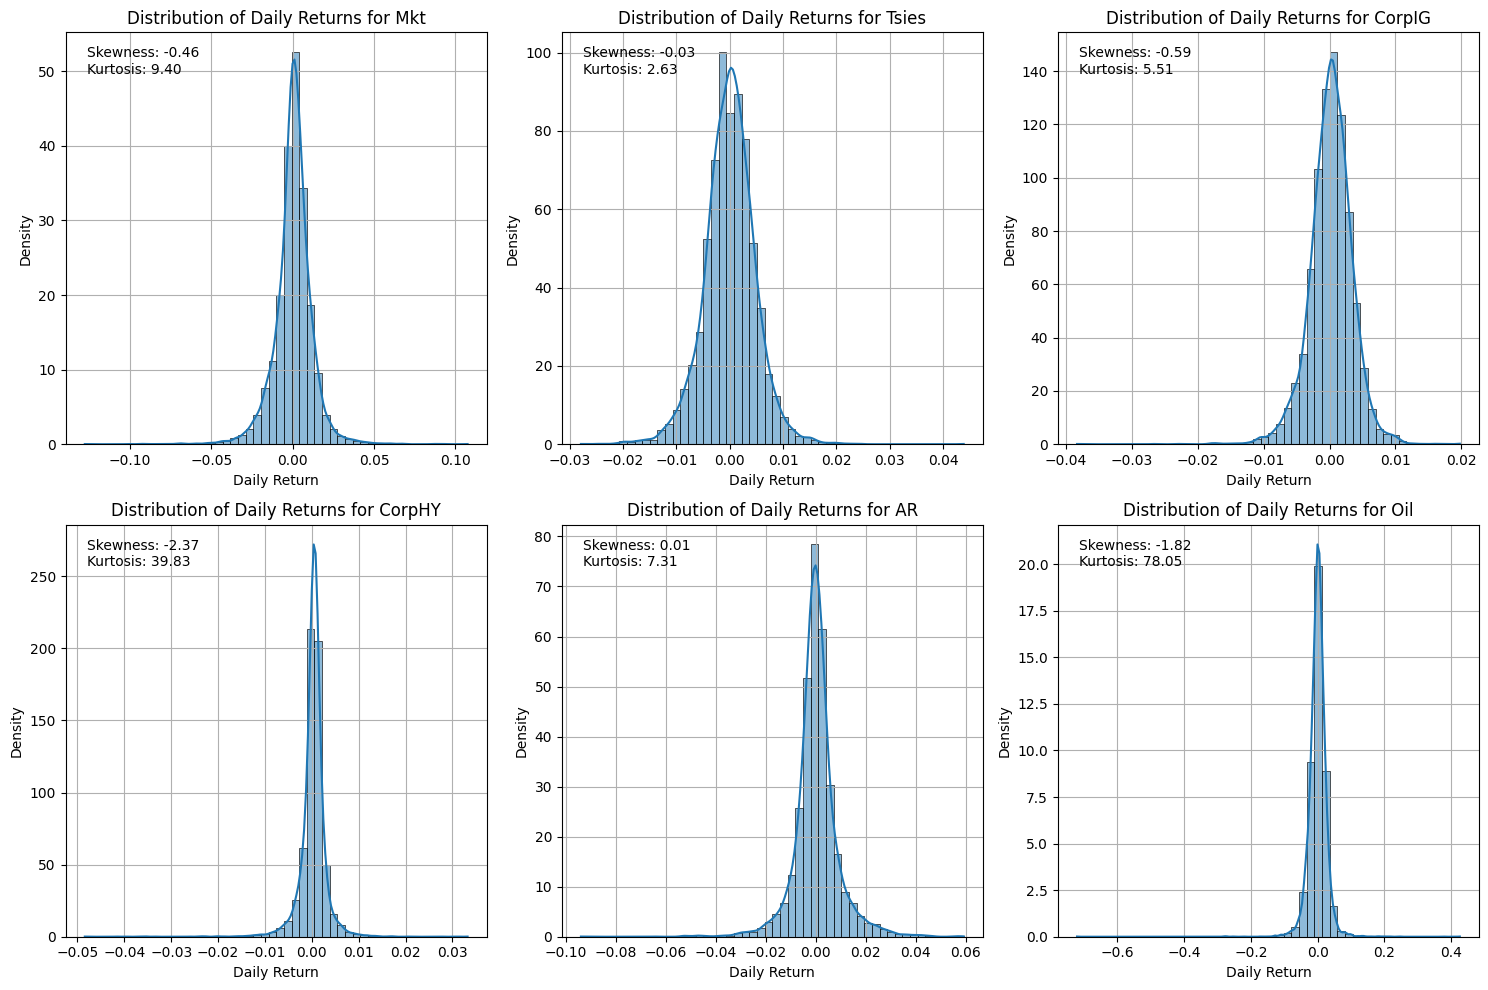

In [132]:
# So first if we plot the distribution of the returns of each asset class:
import seaborn as sns
import math

def plot_return_distributions(returns_df):
    num_plots = len(returns_df.columns)
    cols = 3
    rows = math.ceil(num_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()  # Convert to a 1D array for easier indexing

    for i, column in enumerate(returns_df.columns):
        sns.histplot(returns_df[column], kde=True, stat="density", bins=50, ax=axes[i])
        axes[i].set_title(f'Distribution of Daily Returns for {column}')
        axes[i].set_xlabel('Daily Return')
        axes[i].set_ylabel('Density')

        skewness = returns_df[column].skew()
        kurtosis = returns_df[column].kurt()
        axes[i].text(0.05, 0.9, f"Skewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}", transform=axes[i].transAxes)
        axes[i].grid(True)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_return_distributions(returns)

Problem with the distribution of returns to express tail risk (lecture 5):

- "Skewness & kurtosis have large sampling error (s.e.),
and provide only limited information to the form of the tails"
- They are just one number summarizing, do not give us any additional info

- So we use the CRAP:Cumulative Ranked Amplitude Plot instead

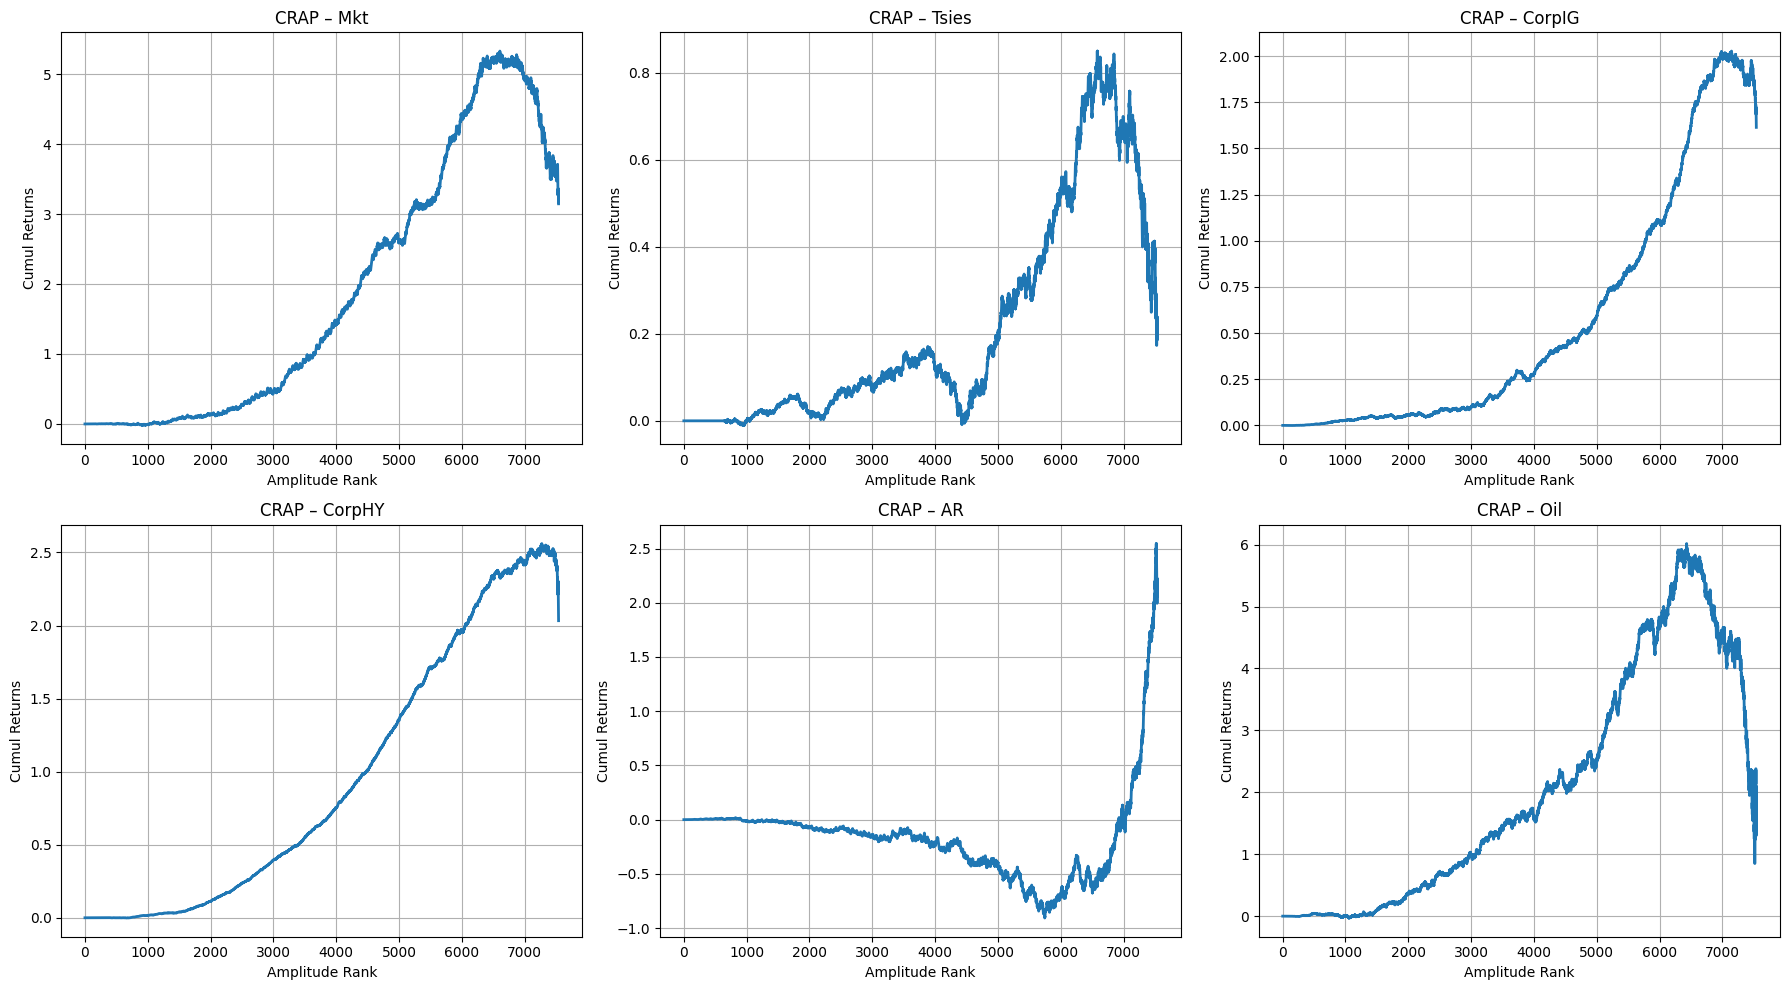

In [133]:
def plot_crap_subplot(returns, ax, asset_class_name):
    amplitudes = returns.abs()
    sorted_index = amplitudes.sort_values().index
    sorted_returns = returns.loc[sorted_index]
    cumulated_returns = sorted_returns.cumsum()

    x_axis = range(1, len(cumulated_returns) + 1)

    ax.plot(x_axis, cumulated_returns.values, linewidth=2)
    ax.set_title(f'CRAP – {asset_class_name}')
    ax.set_xlabel('Amplitude Rank')
    ax.set_ylabel('Cumul Returns')
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, column in enumerate(returns.columns):
    plot_crap_subplot(returns[column], axes[i], column)

for j in range(len(returns.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Plotting CRAP for each asset class:
- Mkt: we observe a max and then a sudden decrease: biggest extreme returns are negative -> deep left tail
- Surprisingly, also the case for Tsies once it has reached a certain point
- But more moderated for other CorpIG and CorpHY (smaller left tail))
- Huge fat negative tail for oil : extreme losses ! -> extreme left tail
- Hedging role for AR: no negative event, but positive ones for the extreme returns -> right tail

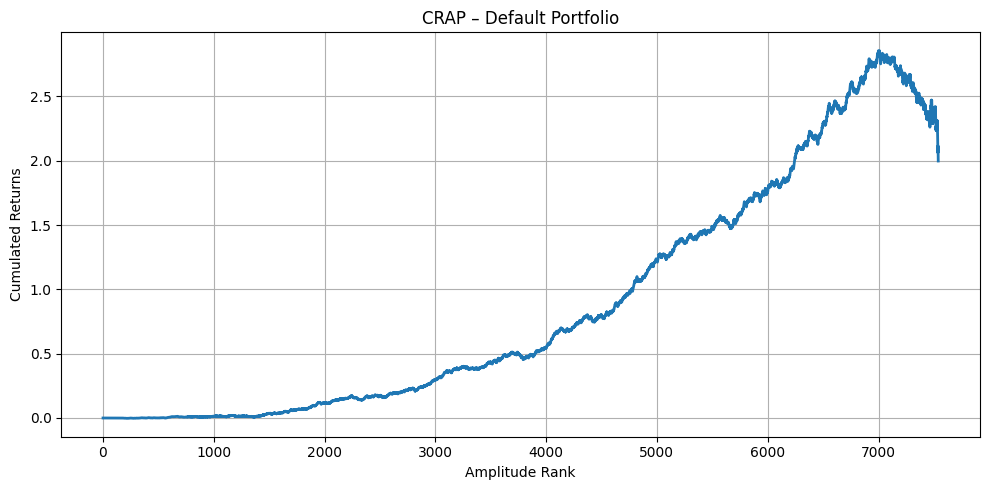

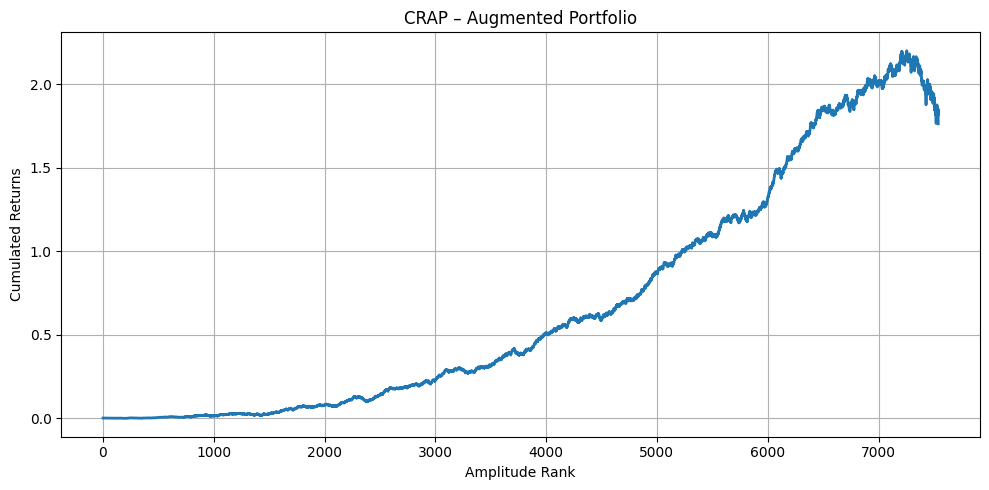

In [134]:
# Plotting the CRAP for default & augmented ptf
def plot_crap(returns, asset_class_name):
    amplitudes = returns.abs()
    sorted_index = amplitudes.sort_values(by=['Return']).index # Specify the column to sort by
    sorted_returns = returns.loc[sorted_index]
    cumulated_returns = sorted_returns.cumsum()
    # Clean x-axis: just the rank from 1 to len(returns)
    x_axis = range(1, len(cumulated_returns) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(x_axis, cumulated_returns.values, linewidth=2)
    plt.title(f'CRAP – {asset_class_name}')
    plt.xlabel('Amplitude Rank')
    plt.ylabel('Cumulated Returns')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_crap(ret_default, "Default Portfolio")
plot_crap(ret_augmented, "Augmented Portfolio")

What we observe:
- Smaller left tail for augmented ptf than for the default one -> it reaches a max and then decreases, but less sharply than for the default one
- Logical: we do not have any oil exposure here (with an extreme left tail), and we decrease the exposure in mkt to allocate more in yields (more moderate).